# $\nu_e$ CC Xsec Analysis

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, sys, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import chi2 as scipy_chi2
from tqdm.auto import tqdm
 
CAFPYANA_WD = '/home/castalyf/cafpyana'
for p in [CAFPYANA_WD, CAFPYANA_WD + '/pyanalib']:
    if p not in sys.path:
        sys.path.insert(0, p)
 
from analysis_village.unfolding.wienersvd import WienerSVD
from analysis_village.unfolding.utils import (
    get_smear_matrix, get_eff, get_response_matrix,
    bin_range_labels, get_text_color,
    plot_overlay_with_cov,
)
 
import nue_helpers as nh
import nue_selection as ns
from nue_xsec_helpers import (
    VariableConfig, load_syst_covariances, build_total_covariance,
    ccbc_constrain, extract_differential_xsec,
    plot_heatmap, plot_uncertainty_budget, save_cov_npz, get_constants,
    SYST_KE_BINS, SYST_COS_BINS, CAT_LABELS, CAT_COLORS,
)
 
mpl.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'figure.dpi': 150, 'axes.grid': False,
})
print("All imports OK")




All imports OK


In [2]:
# %% CELL 1 — Paths & Settings
DF_OUT_DIR   = './nuecc_dfs'
SYST_DIR     = './saved_syst'
PLOT_DIR     = './plots_xsec'
COV_OUT_DIR  = './nuecc_cov'
TARGET_POT   = 6.6e20
TITLE        = r'SBND $\nu_e$ CC Inclusive'
FINAL_STAGE  = 'sel_vertex_distance'
 
SEL_FILE     = f'{DF_OUT_DIR}/selected_nuecc_qual.df'
DF_FILE      = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_v2-2.df'
 
OMNIFOLD_COV = '/home/castalyf/Omnifold_SBND/sbnd/covariance/'
 
SAVE_FIGS = True
for d in [PLOT_DIR, COV_OUT_DIR, f'{PLOT_DIR}/fakedata',
          f'{PLOT_DIR}/omnifold_comparison']:
    os.makedirs(d, exist_ok=True)
 
def savefig(fname, fig=None):
    if SAVE_FIGS:
        (fig or plt.gcf()).savefig(os.path.join(PLOT_DIR, fname),
                                   bbox_inches='tight', dpi=150)
print("Paths OK")


Paths OK


In [3]:
# %% CELL 2 — Load sel_topo
st = nh.load_sel_topo(SEL_FILE, df_file=DF_FILE)
sel_topo  = st['sel_topo']
pot_scale = st['pot_scale']
 
sel_final = sel_topo[sel_topo[FINAL_STAGE]]
sig_mask  = (sel_final['truth_cat'] == 0)
bkg_mask  = sel_final['truth_cat'].between(1, 6)
 
n_sig, n_bkg = sig_mask.sum(), bkg_mask.sum()
n_other = len(sel_final) - n_sig - n_bkg
 
print(f"sel_final: {len(sel_final):,} events")
print(f"  Signal (cat 0):    {n_sig:,}")
print(f"  Background (1-6):  {n_bkg:,}")
print(f"  Other (cat 7 etc): {n_other:,}")
print(f"  Purity (sig/[sig+bkg]): {n_sig/(n_sig+n_bkg)*100:.1f}%")
print(f"  Purity (sig/total):     {n_sig/len(sel_final)*100:.1f}%")


sel_topo shape : (2425112, 16)
pot_scale      : 1.7545
n_true_signal  : 9,418
  sel_precut                          sig= 9,418  total=2,425,112
  sel_valid_flashmatch                sig= 9,418  total=2,425,112
  sel_fiducial                        sig= 9,418  total=2,425,112
  sel_single_electron                 sig= 8,916  total=   69,929
  sel_electron_primary_score          sig= 7,547  total=   37,468
  sel_electron_pid_score              sig= 6,169  total=   11,115
  sel_vertex_distance                 sig= 5,814  total=    9,440
sel_final: 9,440 events
  Signal (cat 0):    5,814
  Background (1-6):  2,446
  Other (cat 7 etc): 1,180
  Purity (sig/[sig+bkg]): 70.4%
  Purity (sig/total):     61.6%


In [4]:
# %% CELL 3 — Variable configs
VAR_CFGS = {
    'reco_ke': VariableConfig(
        'reco_ke', SYST_KE_BINS,
        r'Reco $e^-$ KE [MeV]', save_name='reco_ke'),
    'reco_costheta': VariableConfig(
        'reco_costheta', SYST_COS_BINS,
        r'Reco $e^-$ $\cos\theta$', save_name='reco_costheta'),
}
TRUE_COL_MAP  = {'reco_ke': 'true_ke', 'reco_costheta': 'true_costheta'}
TRUE_BINS_MAP = {'reco_ke': SYST_KE_BINS, 'reco_costheta': SYST_COS_BINS}
 
# True-space labels for unfolded plots
TRUE_LABELS = {
    'reco_ke':       r'True $e^-$ KE [MeV]',
    'reco_costheta': r'True $e^-$ $\cos\theta$',
}


In [5]:
# %% CELL 4 — Response matrix + efficiency
_eps = 1e-8
response_dict = {}
 
for var_name, vcfg in VAR_CFGS.items():
    tc = TRUE_COL_MAP[var_name]
    tb = TRUE_BINS_MAP[var_name]
    bins = vcfg.bins
 
    sig_sel = sel_final[sig_mask].copy()
 
    # Aligned reco + truth
    valid = sig_sel[var_name].notna() & sig_sel[tc].notna()
    reco_a = sig_sel.loc[valid, var_name].clip(bins[0], bins[-1]-_eps).values
    true_a = sig_sel.loc[valid, tc].clip(tb[0], tb[-1]-_eps).values
 
    # CV histograms (POT-weighted)
    sig_reco = sig_sel[var_name].dropna().clip(bins[0], bins[-1]-_eps)
    sig_reco_cv, _ = np.histogram(sig_reco, bins=bins,
                                   weights=np.full(len(sig_reco), pot_scale))
    bkg_sel = sel_final[bkg_mask]
    bkg_reco = bkg_sel[var_name].dropna().clip(bins[0], bins[-1]-_eps)
    bkg_reco_cv, _ = np.histogram(bkg_reco, bins=bins,
                                   weights=np.full(len(bkg_reco), pot_scale))
 
    # All true signal (efficiency denominator, unweighted)
    all_sig = sel_topo[sel_topo['is_sig']]
    all_true = all_sig[tc].dropna().clip(tb[0], tb[-1]-_eps).values
    sig_true_all, _ = np.histogram(all_true, bins=tb)
 
    # Smearing matrix (cafpyana convention)
    reco_vs_true = get_smear_matrix(
        true_a, reco_a, bins,
        var_labels=[vcfg.xlabel]*3, plot=False)
 
    eff = get_eff(reco_vs_true, sig_true_all.astype(float))
 
    # Response matrix: shape (n_reco × n_true)
    Response = get_response_matrix(
        reco_vs_true, eff, bins,
        var_labels=[vcfg.xlabel]*3, plot=False)
 
    # Also build the smearing-only matrix M (row-normalized, n_true × n_reco)
    row_sums = reco_vs_true.sum(axis=1, keepdims=True)
    Smearing = np.divide(reco_vs_true, row_sums,
                         out=np.zeros_like(reco_vs_true, dtype=float),
                         where=row_sums > 0)
 
    response_dict[var_name] = dict(
        response=Response, smearing=Smearing,
        reco_vs_true=reco_vs_true, efficiency=eff,
        sig_reco_cv=sig_reco_cv, bkg_reco_cv=bkg_reco_cv,
        sig_true_cv=sig_true_all.astype(float),
    )
 
    print(f"\n{var_name}:")
    print(f"  Response {Response.shape}, Smearing {Smearing.shape}")
    print(f"  Smearing diag = {np.round(np.diag(Smearing), 3)}")
    print(f"  Smearing diag mean = {np.mean(np.diag(Smearing)):.4f}")
    print(f"  Response diag = {np.round(np.diag(Response), 3)}")
    print(f"  Response col sums (= eff) = {np.round(Response.sum(axis=0), 3)}")
    print(f"  Efficiency = {np.round(eff, 3)}")
    print(f"  Purity: {sig_reco_cv.sum()/(sig_reco_cv+bkg_reco_cv).sum()*100:.1f}%")



reco_ke:
  Response (7, 7), Smearing (7, 7)
  Smearing diag = [0.893 0.908 0.854 0.776 0.768 0.725 0.833]
  Smearing diag mean = 0.8223
  Response diag = [0.192 0.502 0.553 0.579 0.621 0.599 0.721]
  Response col sums (= eff) = [0.215 0.553 0.648 0.747 0.809 0.826 0.866]
  Efficiency = [0.215 0.553 0.648 0.747 0.809 0.826 0.866]
  Purity: 70.4%

reco_costheta:
  Response (10, 10), Smearing (10, 10)
  Smearing diag = [0.936 0.806 0.773 0.802 0.786 0.78  0.816 0.838 0.842 0.903]
  Smearing diag mean = 0.8283
  Response diag = [0.282 0.28  0.26  0.232 0.319 0.383 0.389 0.487 0.537 0.66 ]
  Response col sums (= eff) = [0.301 0.347 0.336 0.289 0.406 0.492 0.477 0.581 0.638 0.731]
  Efficiency = [0.301 0.347 0.336 0.289 0.406 0.492 0.477 0.581 0.638 0.731]
  Purity: 70.4%


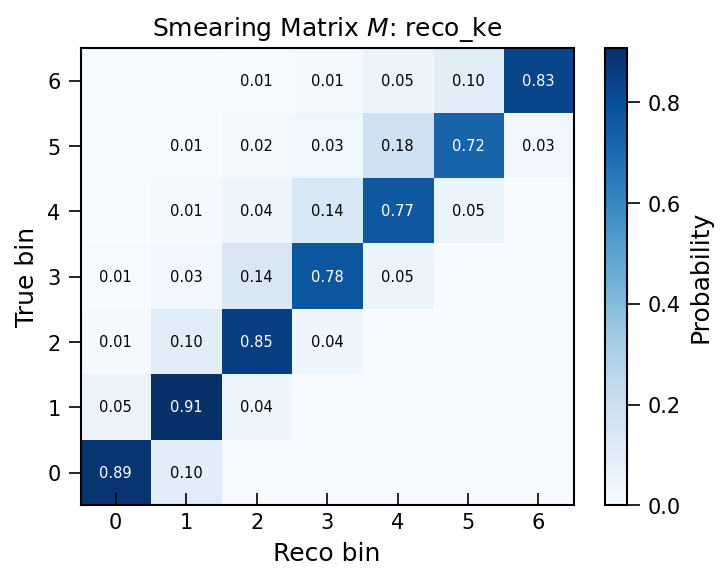

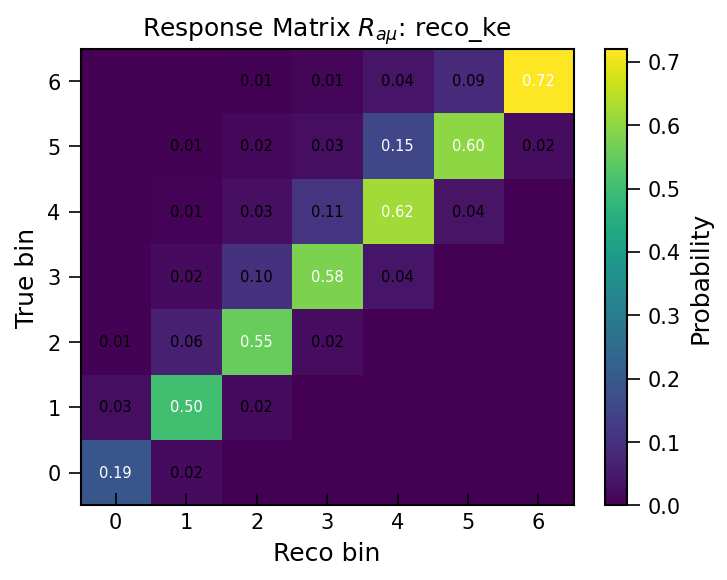

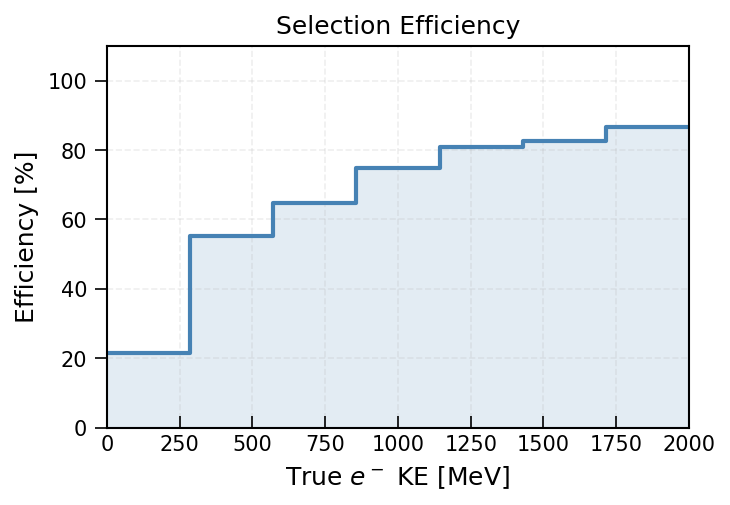

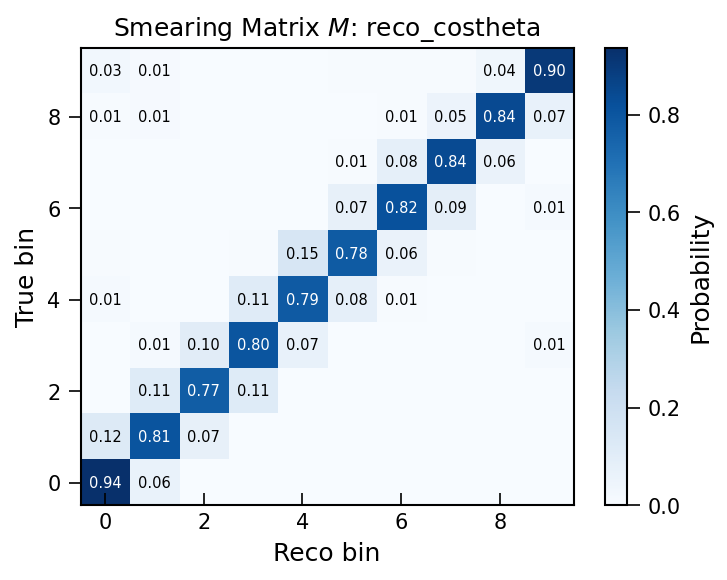

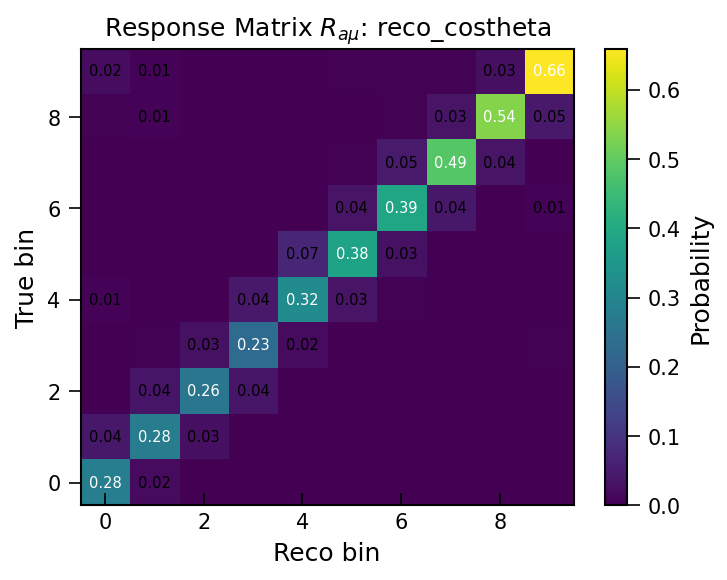

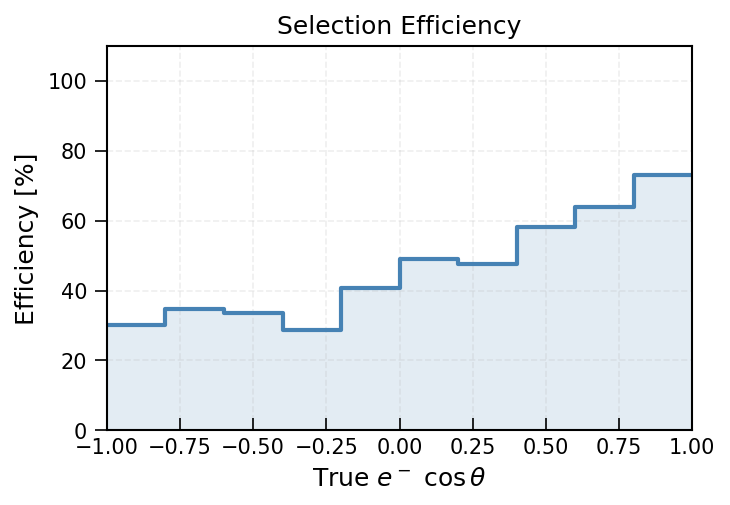

In [6]:
# %% CELL 5 — Plot smearing matrix + response matrix + efficiency
# ══════════════════════════════════════════════════════════════════════════════
# Smearing matrix M: same as syst notebook (diag ~0.8)
# Response matrix R = ε × M: includes efficiency (diag ~0.2–0.7)
# Lynn's Fig 21 shows R, with values 0.16–0.29
 
for var_name, vcfg in VAR_CFGS.items():
    rd = response_dict[var_name]
    n = vcfg.n_bins
 
    # ── Smearing matrix M (matches syst notebook style) ───────────────────
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(rd['smearing'], origin='lower', cmap='Blues', aspect='auto')
    ax.set_xlabel('Reco bin'); ax.set_ylabel('True bin')
    ax.set_title(f'Smearing Matrix $M$: {var_name}')
    plt.colorbar(im, ax=ax, label='Probability')
    # Annotate
    for i in range(n):
        for j in range(n):
            v = rd['smearing'][i, j]
            if v > 0.005:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if v > 0.5 else 'black')
    plt.tight_layout(); savefig(f'{var_name}_smearing_matrix.png'); plt.show()
 
    # ── Response matrix R (Lynn's Fig 21 style) ───────────────────────────
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(rd['response'].T, origin='lower', cmap='viridis', aspect='auto')
    # Note: Response is (n_reco × n_true), transpose to show true on y-axis
    ax.set_xlabel('Reco bin'); ax.set_ylabel('True bin')
    ax.set_title(f'Response Matrix $R_{{a\\mu}}$: {var_name}')
    plt.colorbar(im, ax=ax, label='Probability')
    for i in range(n):
        for j in range(n):
            v = rd['response'].T[i, j]  # [true, reco]
            if abs(v) > 0.005:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if v > 0.15 else 'black')
    plt.tight_layout(); savefig(f'{var_name}_response_matrix.png'); plt.show()
 
    # ── Efficiency ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 3.5))
    eff = rd['efficiency']
    ax.step(vcfg.bins, np.append(eff*100, eff[-1]*100),
            where='post', color='steelblue', lw=2)
    ax.fill_between(vcfg.bins, np.append(eff*100, eff[-1]*100),
                    step='post', alpha=0.15, color='steelblue')
    ax.set_xlim(vcfg.bins[0], vcfg.bins[-1]); ax.set_ylim(0, 110)
    ax.set_xlabel(TRUE_LABELS[var_name]); ax.set_ylabel('Efficiency [%]')
    ax.set_title(f'Selection Efficiency')
    ax.grid(alpha=0.2, ls='--')
    plt.tight_layout(); savefig(f'{var_name}_efficiency.png'); plt.show()


In [7]:
# %% CELL 6 — Load systematic covariances
SYST_SOURCES = ['flux', 'genie', 'extra_xsec', 'g4', 'mcstat', 'pot', 'ntargets']
SRC_LABELS = {
    'flux': 'BNB Flux', 'genie': 'GENIE', 'extra_xsec': 'Extra Xsec',
    'g4': 'Geant4', 'mcstat': 'MC Stat', 'pot': 'Beam Exposure',
    'ntargets': r'$N_\mathrm{targets}$',
}
 
cov_loaded = {}
for var_name in VAR_CFGS:
    cov_loaded[var_name] = load_syst_covariances(SYST_DIR, var_name, SYST_SOURCES)
    print(f"{var_name}: loaded {list(cov_loaded[var_name].keys())}")


reco_ke: loaded ['flux', 'genie', 'extra_xsec', 'g4', 'mcstat', 'pot', 'ntargets']
reco_costheta: loaded ['flux', 'genie', 'extra_xsec', 'g4', 'mcstat', 'pot', 'ntargets']


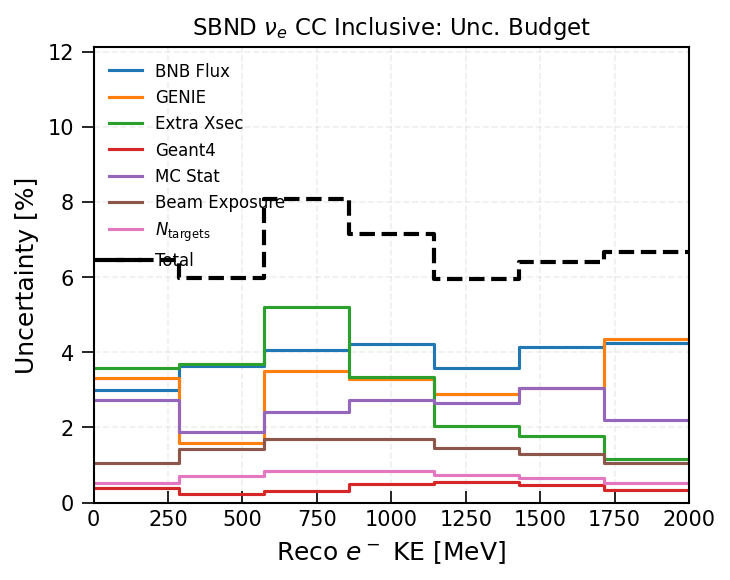

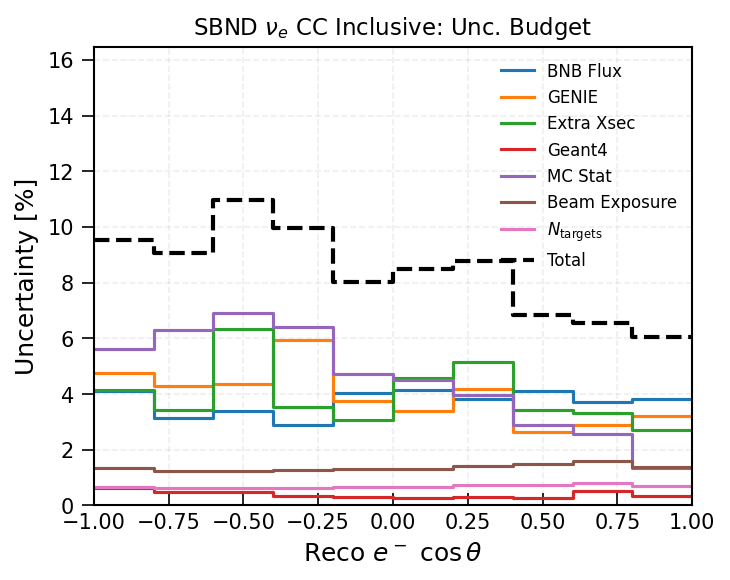

In [8]:
# %% CELL 7 — Uncertainty budget (reco-space, Lynn's slide 8 style)
for var_name, vcfg in VAR_CFGS.items():
    rd = response_dict[var_name]
    cv_total = rd['sig_reco_cv'] + rd['bkg_reco_cv']
    cov_dict_plot = {SRC_LABELS.get(s, s): v['cov_ms_ms']
                     for s, v in cov_loaded[var_name].items() if 'cov_ms_ms' in v}
 
    fig, ax = plot_uncertainty_budget(vcfg, cv_total, cov_dict_plot,
                                      title=f'{TITLE}: Unc. Budget')
    savefig(f'{var_name}_uncertainty_budget.png'); plt.show()
 


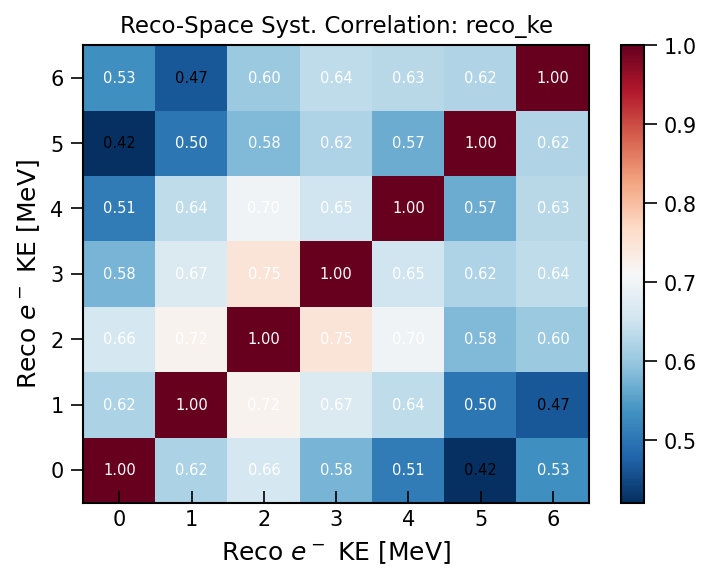

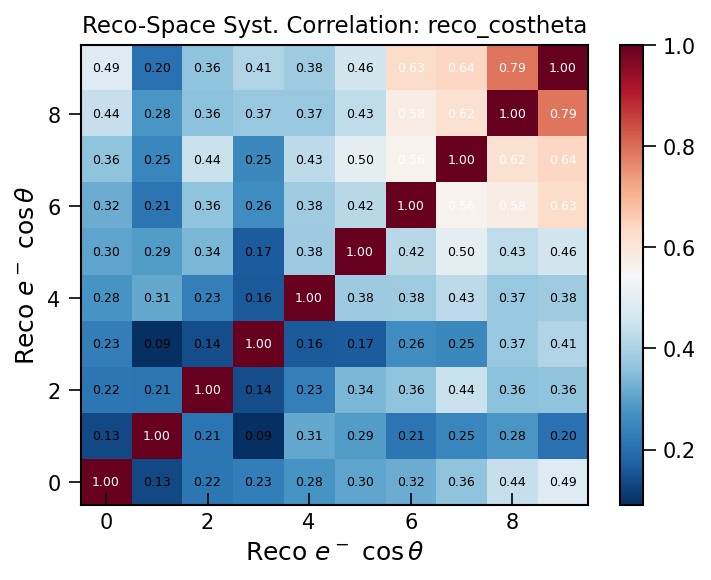

In [9]:
# %% CELL 8 — Reco-space correlation (from systematics)
for var_name, vcfg in VAR_CFGS.items():
    total_cov = build_total_covariance(cov_loaded[var_name], 'cov_ms_ms')
    if total_cov is None: continue
 
    dg = np.sqrt(np.diag(total_cov).clip(1e-10))
    corr = total_cov / np.outer(dg, dg)
 
    fig, ax = plot_heatmap(corr, f'Reco-Space Syst. Correlation: {var_name}',
                            vcfg, cmap='RdBu_r')
    savefig(f'{var_name}_correlation_reco.png'); plt.show()


In [10]:
# %% CELL 9 — Total covariance for unfolding
total_cov_for_unfold = {}
for var_name, vcfg in VAR_CFGS.items():
    total = build_total_covariance(cov_loaded[var_name], 'cov_ms_ms')
    if total is None:
        total = np.diag(response_dict[var_name]['sig_reco_cv'])
    total_cov_for_unfold[var_name] = total



reco_ke: χ²/ndf = 0.00/7 (p = 1.000)


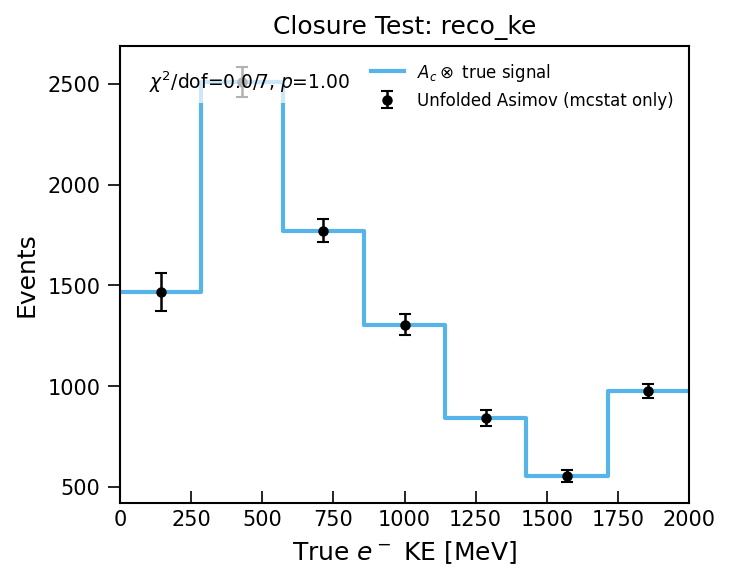


reco_costheta: χ²/ndf = 0.00/10 (p = 1.000)


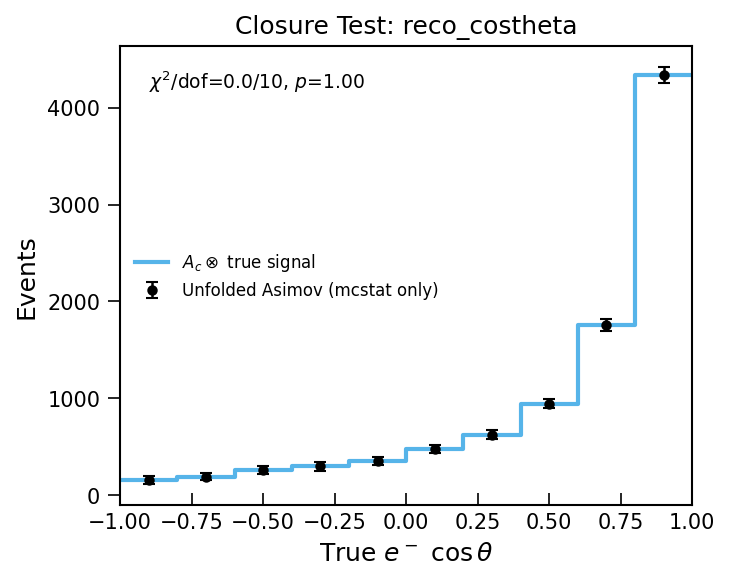

In [11]:
# %% CELL 10 — Wiener-SVD closure test
closure_results = {}
 
for var_name, vcfg in VAR_CFGS.items():
    rd = response_dict[var_name]
    Response = rd['response']  # (n_reco × n_true)
    Model    = rd['sig_true_cv']  # raw truth counts
 
    # Asimov: Measured = R @ Model
    Measured_asimov = Response @ Model
    Cov_mcstat = np.diag(np.maximum(Measured_asimov, 1.0))
 
    unfold = WienerSVD(Response, Model, Measured_asimov, Cov_mcstat,
                       C_type=2, Norm_type=0)
    closure_results[var_name] = unfold
 
    U  = unfold['unfold']
    Uc = unfold['UnfoldCov']
    Ac = unfold['AddSmear']
    ms = Ac @ Model
    c2 = float((U - ms) @ np.linalg.inv(Uc) @ (U - ms))
    ndf = len(U)
    pv = 1 - scipy_chi2.cdf(c2, ndf)
 
    print(f"\n{var_name}: χ²/ndf = {c2:.2f}/{ndf} (p = {pv:.3f})")
 
    # Plot (Lynn's Fig 22 style)
    fig, ax = plt.subplots(figsize=(5, 4))
    centers = vcfg.bin_centers
    Uerr = np.sqrt(np.diag(Uc).clip(0))
    ax.errorbar(centers, U, yerr=Uerr, fmt='ko', capsize=3, ms=4, lw=1.2,
                label='Unfolded Asimov (mcstat only)')
    ax.step(vcfg.bins, np.append(ms, ms[-1]), where='post',
            color='#56B4E9', lw=2, label=r'$A_c \otimes$ true signal')
    ax.text(0.05, 0.95,
            rf'$\chi^2$/dof={c2:.1f}/{ndf}, $p$={pv:.2f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(fc='white', alpha=0.7, ec='none'))
    ax.set_xlabel(TRUE_LABELS[var_name]); ax.set_ylabel('Events')
    ax.set_title(f'Closure Test: {var_name}')
    ax.legend(fontsize=8, frameon=False)
    ax.set_xlim(vcfg.bins[0], vcfg.bins[-1])
    plt.tight_layout(); savefig(f'{var_name}_closure_test.png'); plt.show()


In [12]:
# %% CELL 10b — Debug: check interaction mode columns
# ══════════════════════════════════════════════════════════════════════════════
# Before running FDTs, verify which columns exist for interaction mode.
 
from nue_xsec_helpers import find_interaction_mode_col
 
intmode_col = find_interaction_mode_col(sel_final)
print(f"Interaction mode column in sel_final: {intmode_col}")
 
if intmode_col is not None:
    vals = sel_final[intmode_col].dropna()
    print(f"  Unique values: {sorted(vals.unique())}")
    print(f"  Value counts:")
    for v in sorted(vals.unique()):
        n = (vals == v).sum()
        print(f"    {v}: {n} ({n/len(vals)*100:.1f}%)")
else:
    print("  ⚠ No interaction mode column found!")
    print(f"  Available columns (first 30): {list(sel_final.columns[:30])}")
    print(f"  Try: [c for c in sel_final.columns if 'int' in str(c).lower()]")
    print(f"  → {[c for c in sel_final.columns if 'int' in str(c).lower()]}")
 
# Also check all_sig
all_sig = sel_topo[sel_topo['is_sig']]
intmode_col_sig = find_interaction_mode_col(all_sig)
print(f"\nInteraction mode column in all_sig: {intmode_col_sig}")


Interaction mode column in sel_final: None
  ⚠ No interaction mode column found!
  Available columns (first 30): ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'sel_electron_primary_score', 'sel_electron_pid_score', 'sel_vertex_distance', 'pot_scale']
  Try: [c for c in sel_final.columns if 'int' in str(c).lower()]
  → []

Interaction mode column in all_sig: None


In [31]:
# Single cell — W-SVD tilt FDT χ²/ndf to compare to OmniFold

for var_name in ['reco_ke', 'reco_costheta']:
    key = (var_name, 'tilt_p03')
    U         = fdt_results[key]['unfold']['unfold']
    alt_truth = fdt_results[key]['alt_truth'].astype(float)
    tc        = TRUE_COL_MAP[var_name]  # 'true_ke' or 'true_costheta'
    ndf       = len(U) - 1

    chi2 = np.sum((U - alt_truth)**2 / np.where(alt_truth > 0, alt_truth, 1))

    print(f"  W-SVD {tc} (ndf={ndf}): χ²/ndf = {chi2/ndf:.4f}")
    
print()
print("OmniFold final iteration:")
print("  true_p        (ndf=6): 3.9100")
print("  true_costheta (ndf=9): 0.1400")

  W-SVD true_ke (ndf=6): χ²/ndf = 14.7072
  W-SVD true_costheta (ndf=9): χ²/ndf = 7.5641

OmniFold final iteration:
  true_p        (ndf=6): 3.9100
  true_costheta (ndf=9): 0.1400



FDT: reco_ke
  Scale RES ×0.8:
    χ²_baseline: 6.0/7 (p=0.54)
    χ²_modified: 6.0/7 (p=0.54)
    Δχ² = 0.0


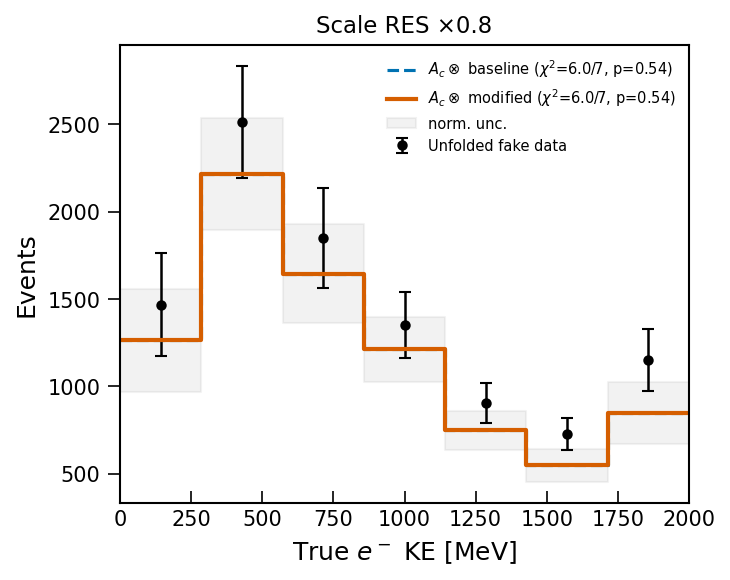

  Scale QE ×1.2:
    χ²_baseline: 6.0/7 (p=0.54)
    χ²_modified: 6.0/7 (p=0.54)
    Δχ² = 0.0


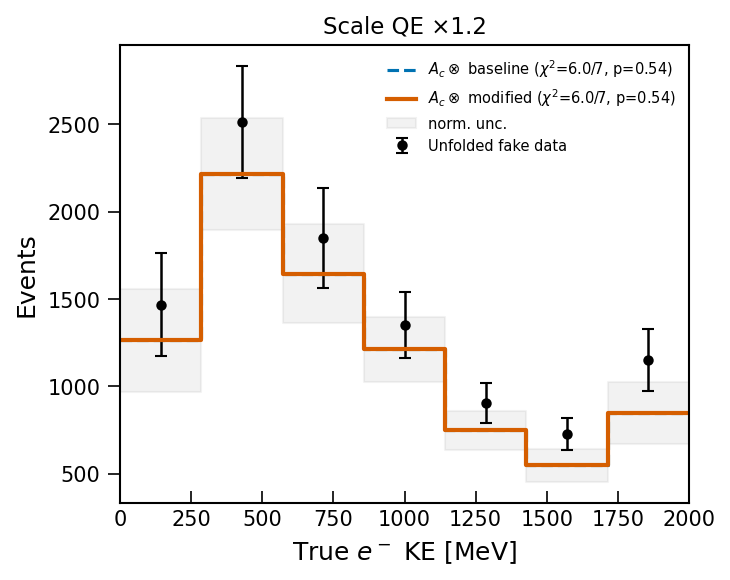

  Scale $\pi^0$ ×0.5:
    χ²_baseline: 2.1/7 (p=0.96)
    χ²_modified: 2.1/7 (p=0.96)
    Δχ² = 0.0


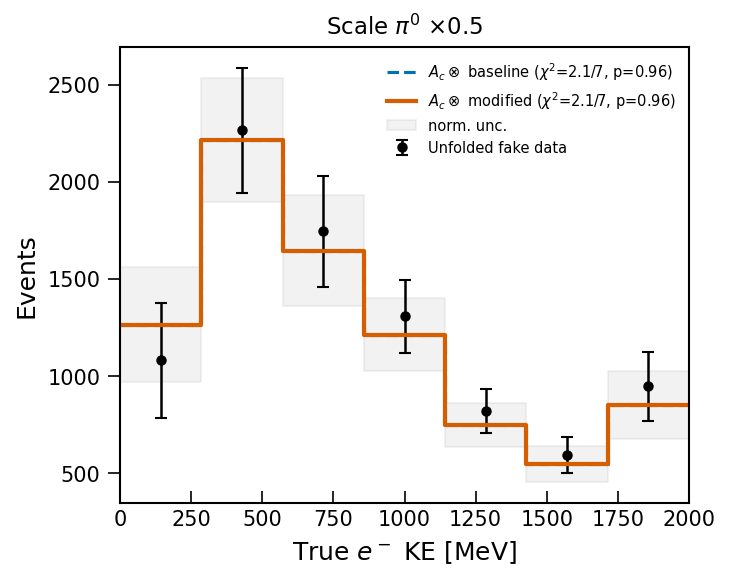

  Suppress low-E ×0.8:
    χ²_baseline: 13.4/7 (p=0.06)
    χ²_modified: 6.2/7 (p=0.51)
    Δχ² = 7.2


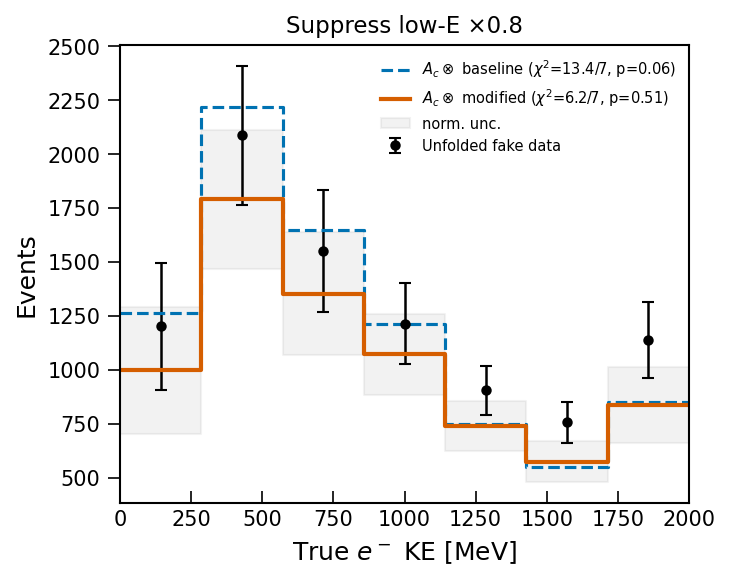

  Tilt $\alpha$=+0.3:
    χ²_baseline: 12.2/7 (p=0.10)
    χ²_modified: 6.0/7 (p=0.54)
    Δχ² = 6.2


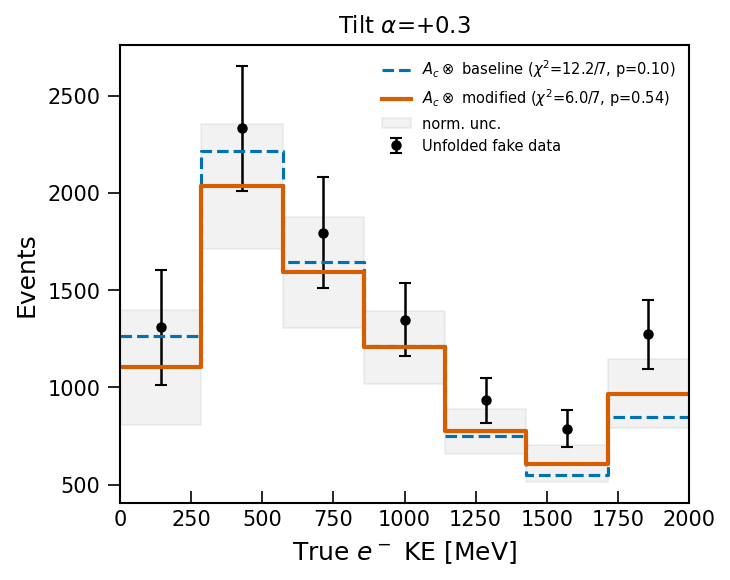

  Tilt $\alpha$=−0.3:
    χ²_baseline: 4.1/7 (p=0.77)
    χ²_modified: 6.0/7 (p=0.54)
    Δχ² = -1.9


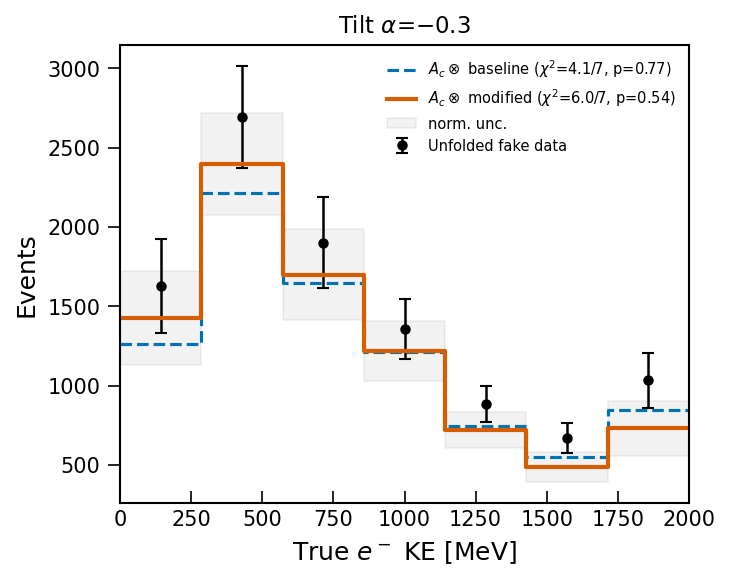


FDT: reco_costheta
  Scale RES ×0.8:
    χ²_baseline: 3.6/10 (p=0.96)
    χ²_modified: 3.6/10 (p=0.96)
    Δχ² = 0.0


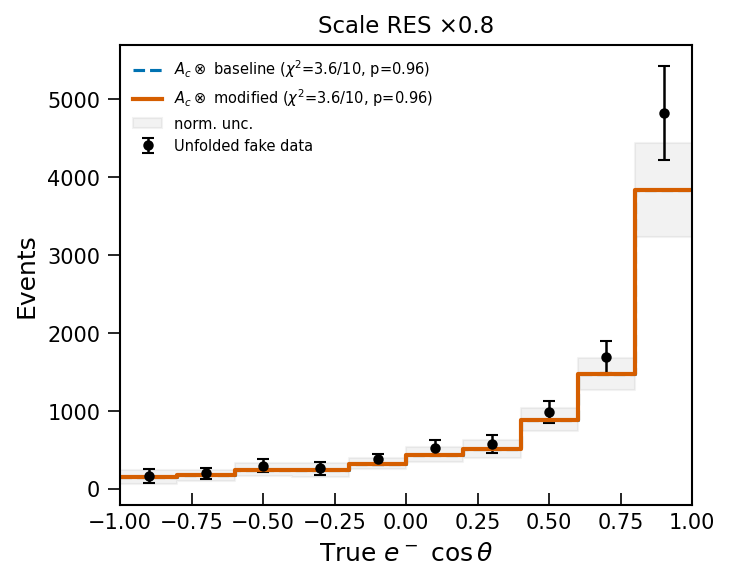

  Scale QE ×1.2:
    χ²_baseline: 3.6/10 (p=0.96)
    χ²_modified: 3.6/10 (p=0.96)
    Δχ² = 0.0


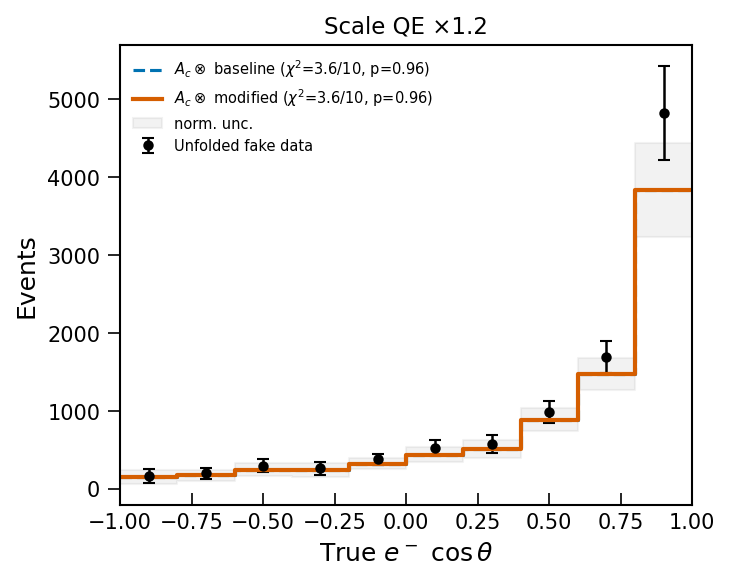

  Scale $\pi^0$ ×0.5:
    χ²_baseline: 0.7/10 (p=1.00)
    χ²_modified: 0.7/10 (p=1.00)
    Δχ² = 0.0


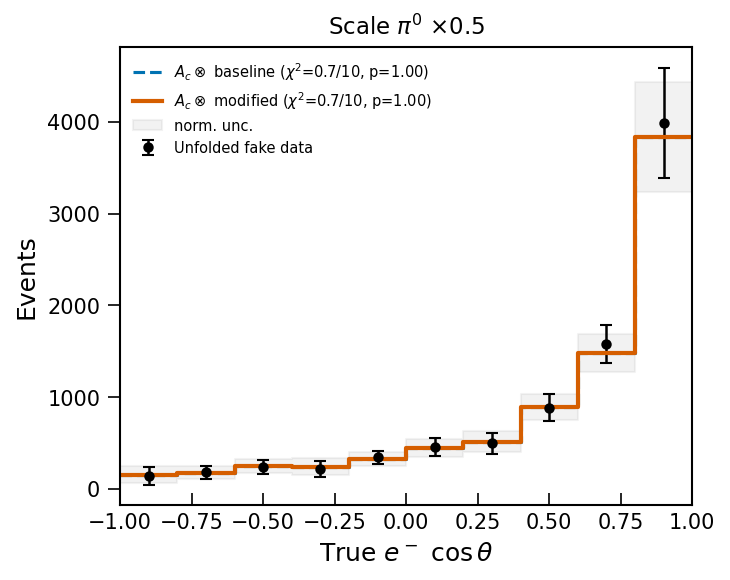

  Suppress low-E ×0.8:
    χ²_baseline: 2.0/10 (p=1.00)
    χ²_modified: 3.6/10 (p=0.96)
    Δχ² = -1.6


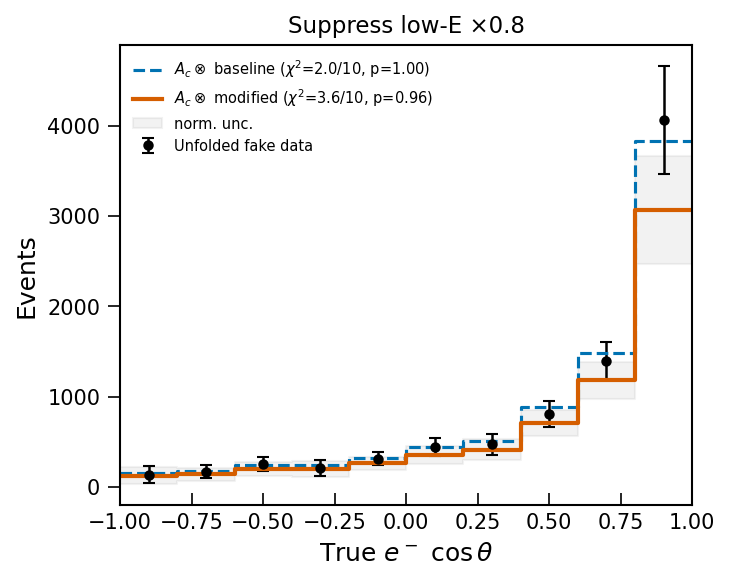

  Tilt $\alpha$=+0.3:
    χ²_baseline: 8.1/10 (p=0.62)
    χ²_modified: 3.7/10 (p=0.96)
    Δχ² = 4.4


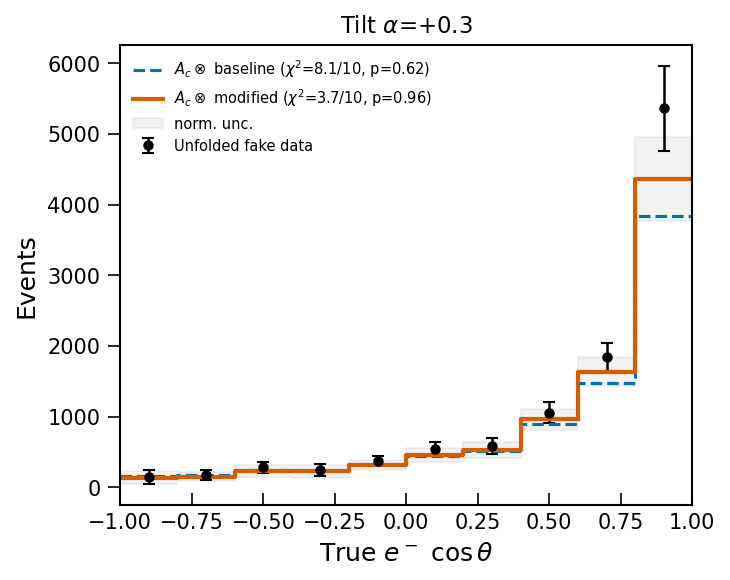

  Tilt $\alpha$=−0.3:
    χ²_baseline: 2.4/10 (p=0.99)
    χ²_modified: 3.6/10 (p=0.96)
    Δχ² = -1.2


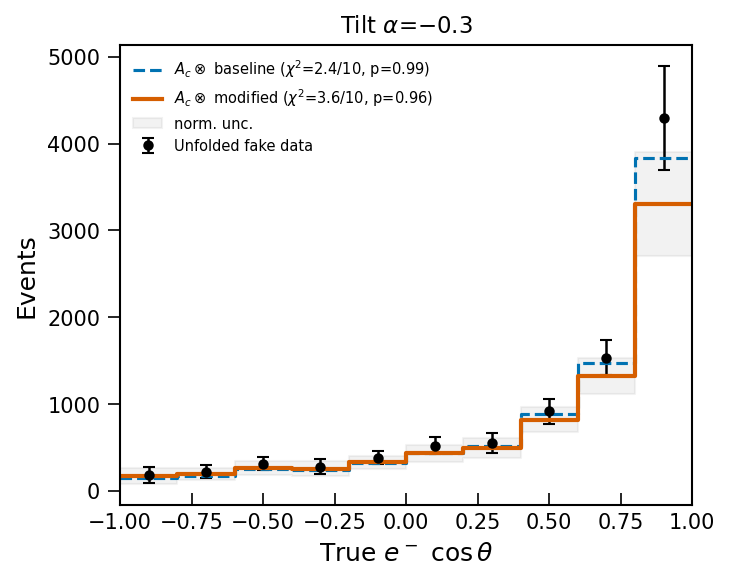


Variable         Test                            χ²_base  p_base   χ²_mod   p_mod     Δχ²
-------------------------------------------------------------------------------------
  reco_ke        Scale RES ×0.8                      6.0    0.54      6.0    0.54     0.0
  reco_ke        Scale QE ×1.2                       6.0    0.54      6.0    0.54     0.0
  reco_ke        Scale $\pi^0$ ×0.5                  2.1    0.96      2.1    0.96     0.0
  reco_ke        Suppress low-E ×0.8                13.4    0.06      6.2    0.51     7.2
  reco_ke        Tilt α=+0.3                        12.2    0.10      6.0    0.54     6.2
  reco_ke        Tilt α=−0.3                         4.1    0.77      6.0    0.54    -1.9
  reco_costheta  Scale RES ×0.8                      3.6    0.96      3.6    0.96     0.0
  reco_costheta  Scale QE ×1.2                       3.6    0.96      3.6    0.96     0.0
  reco_costheta  Scale $\pi^0$ ×0.5                  0.7    1.00      0.7    1.00     0.0
  reco_costhe

In [13]:
# %% CELL 11 — Fake data tests  [uses helper functions]
# ══════════════════════════════════════════════════════════════════════════════
 
from nue_xsec_helpers import (
    build_fdt_weights_intmode, build_fdt_weights_tilt,
    build_fdt_weights_pi0, build_fdt_weights_low_energy,
    run_single_fdt, plot_fdt,
)
 
all_sig = sel_topo[sel_topo['is_sig']]
 
# Define FDT list: (label, tag, weight_builder_fn)
# weight_builder_fn(sel_final, all_sig) -> (evt_wgt, truth_wgt)
 
FDT_LIST = [
    ("Scale RES ×0.8", "res_m20",
     lambda s, a: build_fdt_weights_intmode(s, a, mode_value=1, scale_factor=0.8)),
    ("Scale QE ×1.2", "qe_p20",
     lambda s, a: build_fdt_weights_intmode(s, a, mode_value=0, scale_factor=1.2)),
    (r"Scale $\pi^0$ ×0.5", "pi0_m50",
     lambda s, a: build_fdt_weights_pi0(s, a, scale_factor=0.5)),
]
 
fdt_results = {}
 
for var_name, vcfg in VAR_CFGS.items():
    rd = response_dict[var_name]
    tc = TRUE_COL_MAP[var_name]; tb = TRUE_BINS_MAP[var_name]
    Response = rd['response']; Model = rd['sig_true_cv']
    Cov = total_cov_for_unfold[var_name]
 
    # Build variable-specific FDTs (tilt + low-E suppression)
    var_fdts = FDT_LIST + [
        (f"Suppress low-E ×0.8", "low_e_m20",
         lambda s, a: build_fdt_weights_low_energy(s, a, tc, 1000, 0.8)),
        (r"Tilt $\alpha$=+0.3", "tilt_p03",
         lambda s, a: build_fdt_weights_tilt(s, a, tc, vcfg.bins, 0.3)),
        (r"Tilt $\alpha$=−0.3", "tilt_m03",
         lambda s, a: build_fdt_weights_tilt(s, a, tc, vcfg.bins, -0.3)),
    ]
 
    print(f"\n{'='*50}\nFDT: {var_name}\n{'='*50}")
 
    for label, tag, wgt_fn in var_fdts:
        evt_wgt, truth_wgt = wgt_fn(sel_final, all_sig)
 
        result = run_single_fdt(
            sel_final, sel_topo, var_name, tc, vcfg.bins, tb,
            Response, Model, Cov, evt_wgt, truth_wgt,
            WienerSVD_fn=WienerSVD)
 
        fdt_results[(var_name, tag)] = result
 
        print(f"  {label}:")
        print(f"    χ²_baseline: {result['c2_nom']:.1f}/{result['ndf']} "
              f"(p={result['p_nom']:.2f})")
        print(f"    χ²_modified: {result['c2_mod']:.1f}/{result['ndf']} "
              f"(p={result['p_mod']:.2f})")
        print(f"    Δχ² = {result['c2_nom'] - result['c2_mod']:.1f}")
 
        plot_fdt(vcfg, result, label, TRUE_LABELS[var_name],
                 save_path=os.path.join(PLOT_DIR, f'fakedata/{var_name}_{tag}.png'))
        plt.show()
 
# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Variable':<16} {'Test':<30} {'χ²_base':>8} {'p_base':>7} "
      f"{'χ²_mod':>8} {'p_mod':>7} {'Δχ²':>7}")
print("-" * 85)
for var_name in VAR_CFGS:
    for label, tag, _ in FDT_LIST + [
        ("Suppress low-E ×0.8", "low_e_m20", None),
        (r"Tilt α=+0.3", "tilt_p03", None),
        (r"Tilt α=−0.3", "tilt_m03", None),
    ]:
        key = (var_name, tag)
        if key not in fdt_results: continue
        r = fdt_results[key]
        dc = r['c2_nom'] - r['c2_mod']
        print(f"  {var_name:<14} {label:<30} {r['c2_nom']:>8.1f} {r['p_nom']:>7.2f} "
              f"{r['c2_mod']:>8.1f} {r['p_mod']:>7.2f} {dc:>7.1f}")


N_targets = 1.2313e+30, Φ = 9.6500e-11


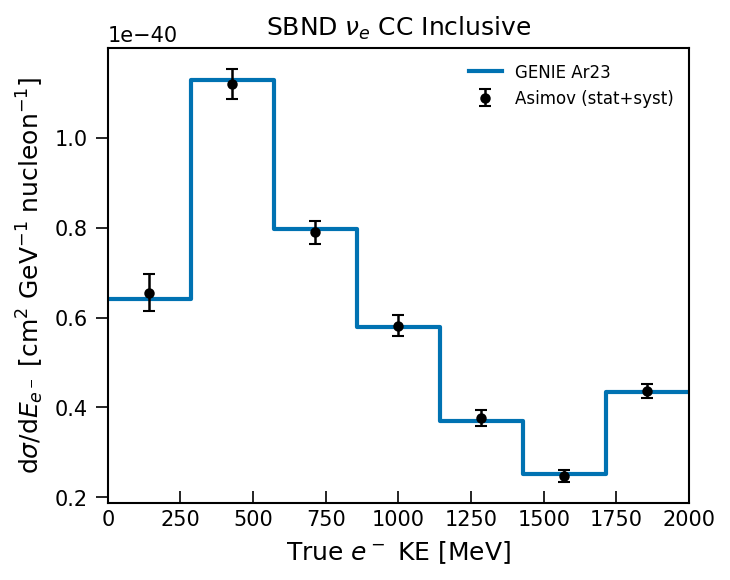

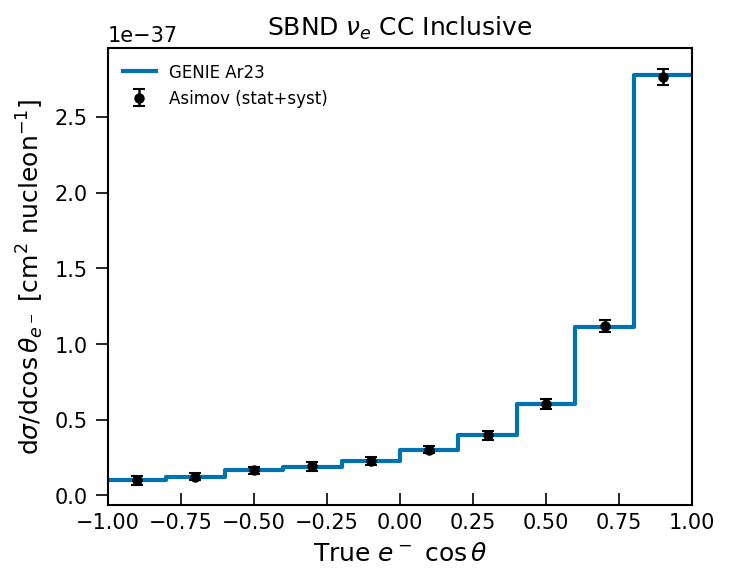

In [14]:
# %% CELL 12 — Cross-section extraction (Asimov)
N_targets, Phi = get_constants()
print(f"N_targets = {N_targets:.4e}, Φ = {Phi:.4e}")
 
xsec_results = {}
for var_name, vcfg in VAR_CFGS.items():
    rd = response_dict[var_name]
    uf = closure_results[var_name]
    U = uf['unfold']; Uc = uf['UnfoldCov']
 
    scale = Phi * TARGET_POT * N_targets * vcfg.bin_widths
    xsec = U / scale
    xsec_cov = Uc / np.outer(scale, scale)
    xsec_unc = np.sqrt(np.diag(xsec_cov).clip(0))
    truth_xsec = rd['sig_true_cv'] / scale
 
    xsec_results[var_name] = dict(
        xsec=xsec, xsec_unc=xsec_unc, xsec_cov=xsec_cov,
        truth_xsec=truth_xsec)
 
    # Plot (Lynn's slide 17 style)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.step(vcfg.bins, np.append(truth_xsec, truth_xsec[-1]),
            where='post', color='#0072B2', lw=2, label='GENIE Ar23')
    ax.errorbar(vcfg.bin_centers, xsec, yerr=xsec_unc,
                fmt='ko', capsize=3, ms=4, lw=1.2, label='Asimov (stat+syst)')
    ax.set_xlabel(TRUE_LABELS[var_name])
    if 'ke' in var_name:
        ax.set_ylabel(r'd$\sigma$/d$E_{e^-}$ [cm$^2$ GeV$^{-1}$ nucleon$^{-1}$]')
    else:
        ax.set_ylabel(r'd$\sigma$/d$\cos\theta_{e^-}$ [cm$^2$ nucleon$^{-1}$]')
    ax.set_title(f'{TITLE}')
    ax.legend(fontsize=8, frameon=False)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
    ax.set_xlim(vcfg.bins[0], vcfg.bins[-1])
    plt.tight_layout(); savefig(f'{var_name}_xsec_asimov.png'); plt.show()


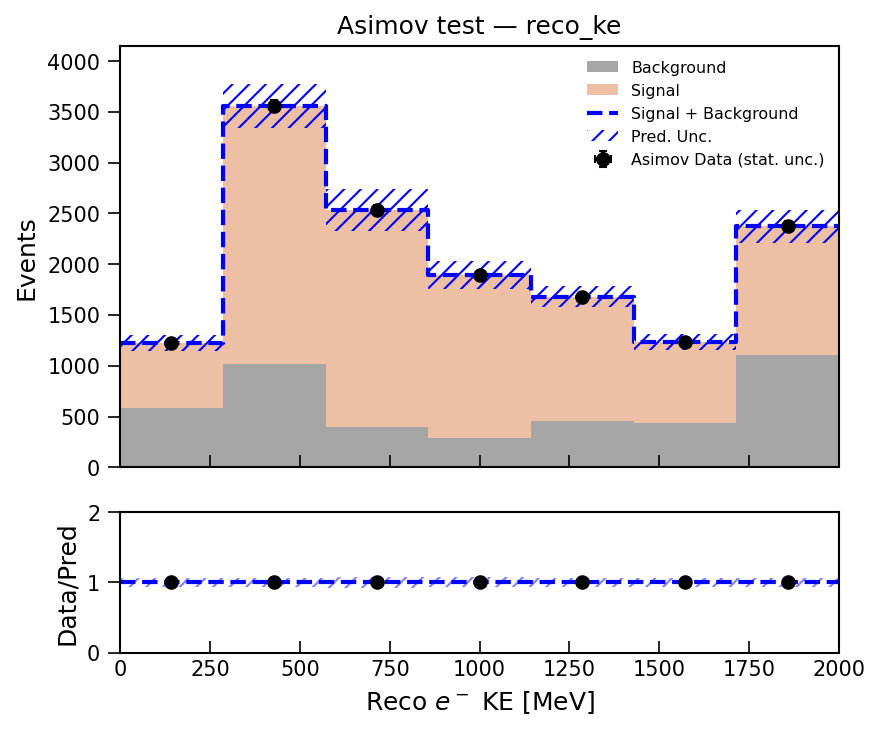

<Figure size 1200x900 with 0 Axes>

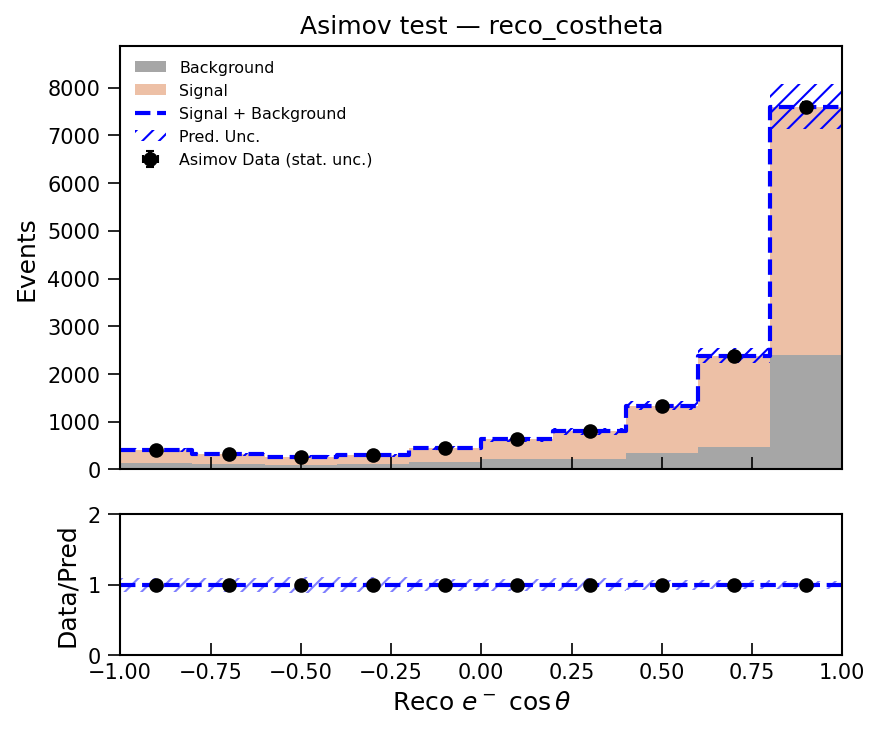

<Figure size 1200x900 with 0 Axes>

In [15]:
for var_name, vcfg in VAR_CFGS.items():
    rd = response_dict[var_name]

    class _VCfg:
        bins = vcfg.bins
        var_labels = [vcfg.xlabel, vcfg.xlabel, TRUE_LABELS[var_name]]
        var_plot_name = vcfg.xlabel

    plot_overlay_with_cov(
        data=rd['sig_reco_cv'] + rd['bkg_reco_cv'],
        cov_data=np.diag(rd['sig_reco_cv'] + rd['bkg_reco_cv']),
        signal=rd['sig_reco_cv'],
        cov_signal=total_cov_for_unfold[var_name],
        background=rd['bkg_reco_cv'],
        cov_background=np.diag(rd['bkg_reco_cv']),
        varcfg=_VCfg(),
        title=f'Asimov test — {var_name}',
        data_label='Asimov Data (stat. unc.)',
        y_label_top='Events',
    )
    savefig(f'{var_name}_asimov_overlay.png'); plt.show()


  Using tilt α=+0.3 FDT covariance for W-SVD comparison

  Wiener-SVD vs OmniFold: reco_ke
  Metric                       Wiener-SVD     OmniFold
  ──────────────────────────────────────────────────
  Condition number                  239.3     210931.7
  Effective DoF                      1.50         1.62
    (out of n_bins)                     7            7
  Mean |off-diag corr|              0.546        0.433
  Frac negative corr                 0.00         0.43
  Total frac unc [%]                 12.0          1.9
  ──────────────────────────────────────────────────
  Per-bin frac unc [%]:
    Wiener-SVD: [22.6 13.8 15.9 14.  12.2 11.9 13.8]
    OF:    [8.4 5.8 3.7 2.6 2.4 2.8 3.9]
  Shape-only unc [%]:
    Wiener-SVD: [15.6  8.2  7.   7.7  9.4  9.8  9.7]
    OF:    [7.6 4.8 2.5 1.6 2.  2.7 4.1]

  Interpretation:
    ⚠ OF cov near-singular (cond=210932) — χ² tests unreliable
    ⚠ OF eff. DoF < 2 — differential shape info very limited
    → OF has lower total unc (1.9% vs 12

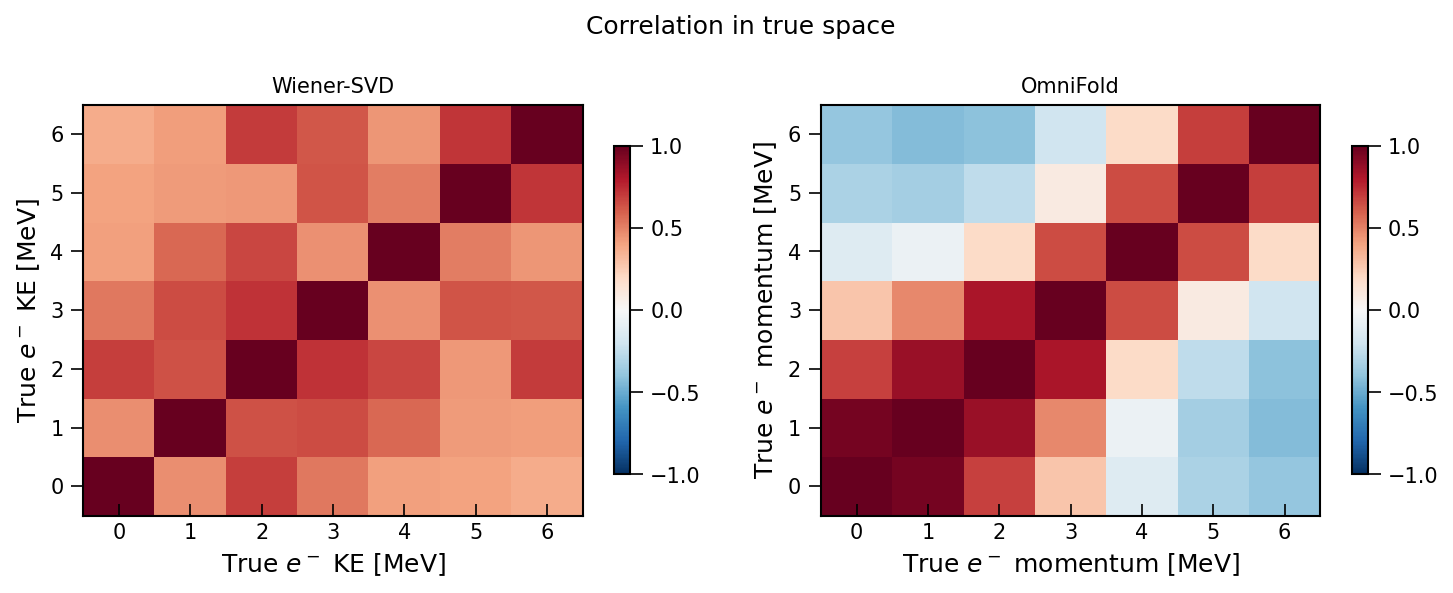

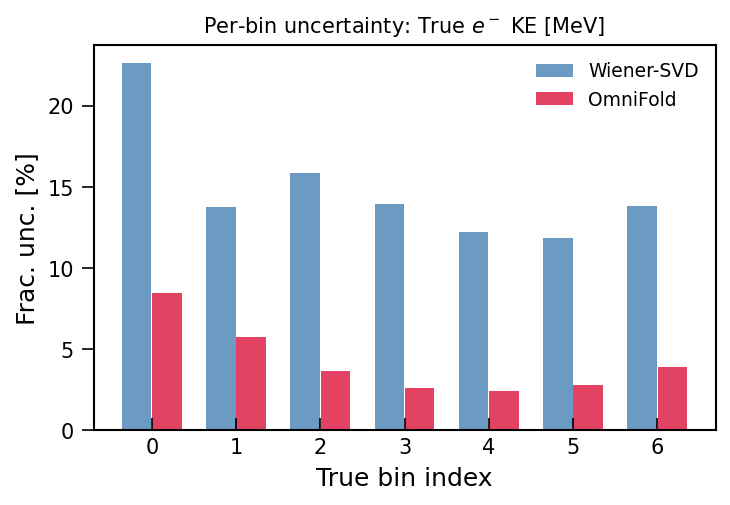

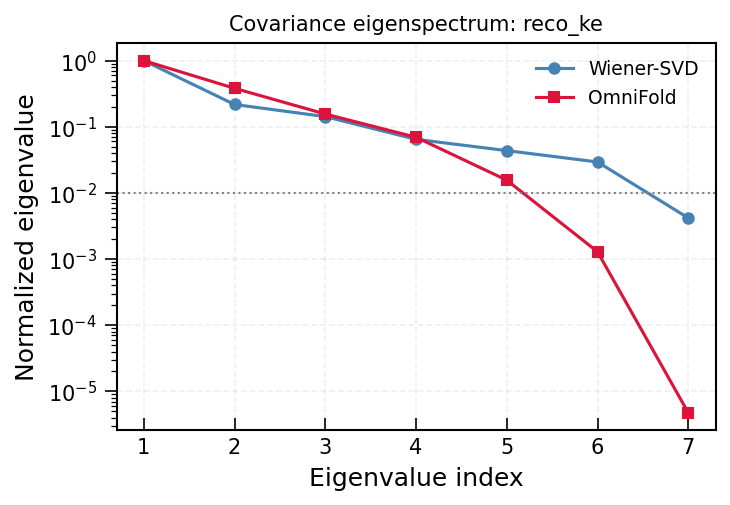


  Using tilt α=+0.3 FDT covariance for W-SVD comparison

  Wiener-SVD vs OmniFold: reco_costheta
  Metric                       Wiener-SVD     OmniFold
  ──────────────────────────────────────────────────
  Condition number                27648.9    8909711.9
  Effective DoF                      1.20         1.20
    (out of n_bins)                    10           10
  Mean |off-diag corr|              0.292        0.577
  Frac negative corr                 0.13         0.20
  Total frac unc [%]                 10.5          1.9
  ──────────────────────────────────────────────────
  Per-bin frac unc [%]:
    Wiener-SVD: [64.  38.7 27.9 35.9 19.8 18.1 19.4 13.7 11.1 11.2]
    OF:    [12.8 11.2  9.5  8.1  6.7  5.6  4.8  4.   2.5  2.9]
  Shape-only unc [%]:
    Wiener-SVD: [62.8 38.  24.9 34.  17.  14.2 14.5  7.4  6.9  4.1]
    OF:    [12.4 10.7  9.   7.7  6.2  5.1  4.3  3.5  2.1  2.3]

  Interpretation:
    ⚠ OF cov near-singular (cond=8909712) — χ² tests unreliable
    ⚠ OF eff. DoF < 

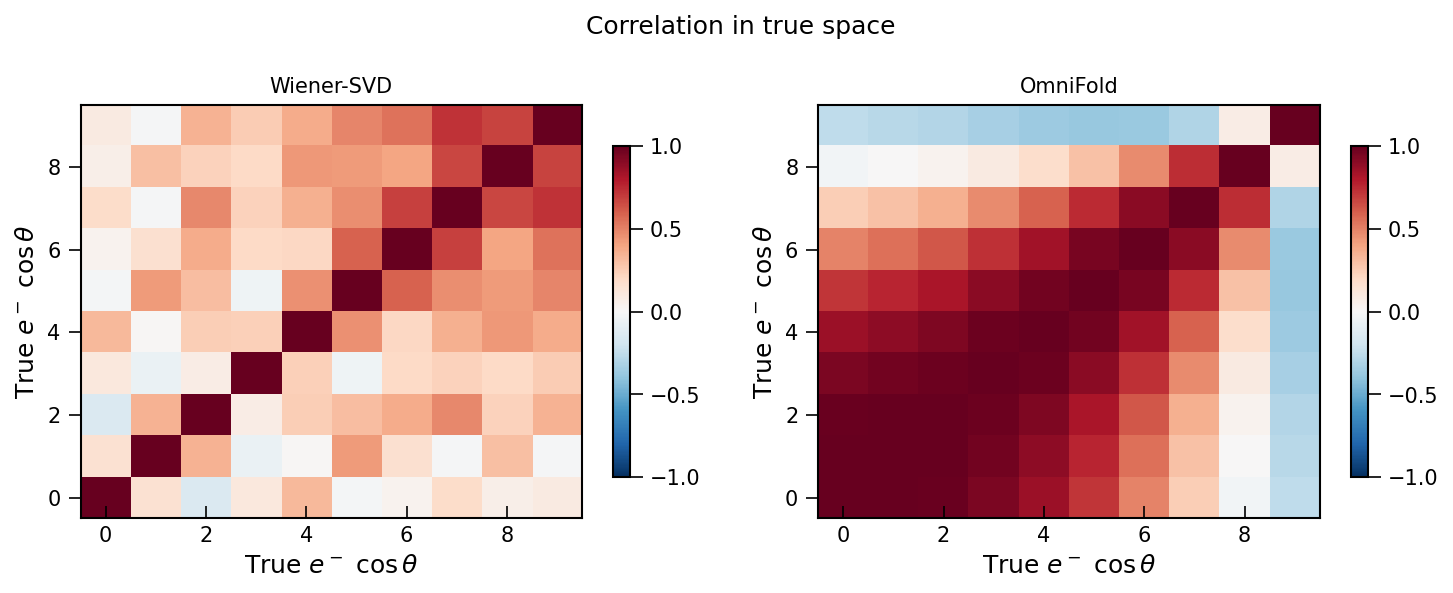

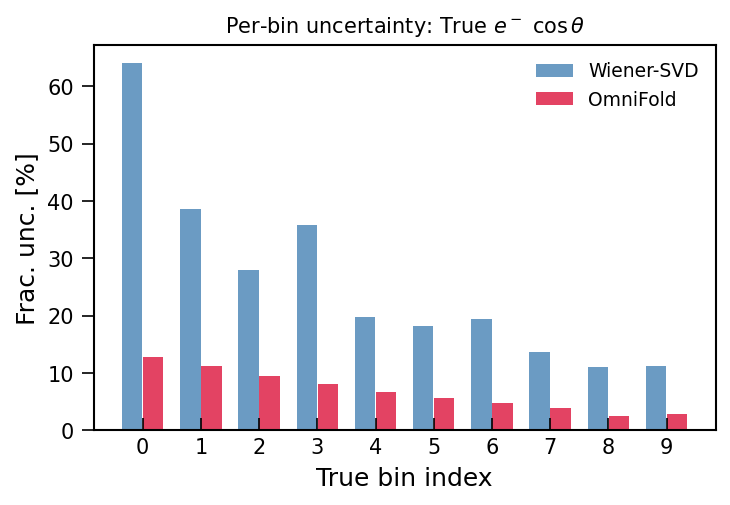

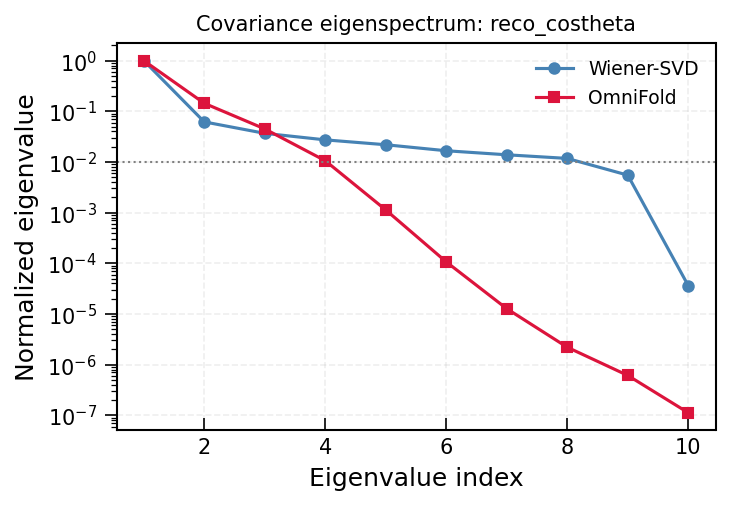

In [24]:
# %% CELL 13 — OmniFold comparison  [diagnostics as printout, plots separate]
# ══════════════════════════════════════════════════════════════════════════════
 
from nue_xsec_helpers import (
    compute_comparison_metrics, print_comparison_metrics,
    plot_comparison_correlations, plot_comparison_frac_unc, plot_eigenspectrum,
)
 
OF_VAR_MAP = {'reco_ke': 'true_p', 'reco_costheta': 'true_costheta'}
 
for var_name, vcfg in VAR_CFGS.items():
    of_var = OF_VAR_MAP.get(var_name)
    if of_var is None: continue
 
    of_cov_file = os.path.join(OMNIFOLD_COV, f'covariance_all_{of_var}.npz')
    if not os.path.exists(of_cov_file):
        print(f"  {var_name}: OmniFold cov not found"); continue
 
    of_data = np.load(of_cov_file)
    of_cov = of_data['cov']; of_mean = of_data['mean_hist']
 
    # Use the TILT FDT covariance for W-SVD if available,
    # otherwise use the closure (Asimov) covariance
    tilt_key = (var_name, 'tilt_p03')
    if tilt_key in fdt_results:
        w_cov = fdt_results[tilt_key]['unfold']['UnfoldCov']
        w_mean = fdt_results[tilt_key]['unfold']['unfold']
        print(f"\n  Using tilt α=+0.3 FDT covariance for W-SVD comparison")
    else:
        w_cov = closure_results[var_name]['UnfoldCov']
        w_mean = closure_results[var_name]['unfold']
        print(f"\n  Using Asimov closure covariance for W-SVD comparison")
 
    # ── Diagnostics (printout) ────────────────────────────────────────────
    metrics = compute_comparison_metrics(w_cov, of_cov, w_mean, of_mean)
    print_comparison_metrics(metrics, var_name)
 
    # ── Plots (separate from diagnostics) ─────────────────────────────────
    # Use accurate variable names for each method
    tl_wsvd = TRUE_LABELS[var_name]  # "True e⁻ KE [MeV]"
    tl_of = {'true_p': r'True $e^-$ momentum [MeV]',
             'true_costheta': r'True $e^-$ $\cos\theta$'}[of_var]

    # Override plot_comparison_correlations to use separate labels
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im1 = axes[0].imshow(metrics['w_corr'], origin='lower', aspect='auto',
                          vmin=-1, vmax=1, cmap='RdBu_r')
    axes[0].set_title('Wiener-SVD', fontsize=10)
    axes[0].set_xlabel(tl_wsvd); axes[0].set_ylabel(tl_wsvd)
    plt.colorbar(im1, ax=axes[0], shrink=0.8)

    im2 = axes[1].imshow(metrics['of_corr'], origin='lower', aspect='auto',
                          vmin=-1, vmax=1, cmap='RdBu_r')
    axes[1].set_title('OmniFold', fontsize=10)
    axes[1].set_xlabel(tl_of); axes[1].set_ylabel(tl_of)
    plt.colorbar(im2, ax=axes[1], shrink=0.8)

    plt.suptitle(f'Correlation in true space', fontsize=12)
    plt.tight_layout()
    savefig(f'omnifold_comparison/corr_truth_{var_name}.png'); plt.show()
    
    tl = TRUE_LABELS[var_name]
 
    plot_comparison_frac_unc(
        metrics, tl,
        save_path=os.path.join(PLOT_DIR,
                               f'omnifold_comparison/frac_unc_{var_name}.png'))
    plt.show()
 
    plot_eigenspectrum(
        metrics, var_name,
        save_path=os.path.join(PLOT_DIR,
                               f'omnifold_comparison/eigenspectrum_{var_name}.png'))
    plt.show()


In [17]:
for var_name in VAR_CFGS:
    of_var = OF_VAR_MAP.get(var_name)
    if of_var is None: continue
    of_cov_file = os.path.join(OMNIFOLD_COV, f'covariance_all_{of_var}.npz')
    if not os.path.exists(of_cov_file): continue

    of_data = np.load(of_cov_file)
    of_cov = of_data['cov']; of_mean = of_data['mean_hist']
    w_cov = closure_results[var_name]['UnfoldCov']
    w_mean = closure_results[var_name]['unfold']

    print(f"\n{'='*50}\n{var_name}: Additional metrics\n{'='*50}")

    # 1. Condition number — how ill-posed is the covariance?
    print(f"  Condition number:  W-SVD={np.linalg.cond(w_cov):.1f}, "
          f"OF={np.linalg.cond(of_cov):.1f}")
    print(f"    (lower = more stable inversion for χ² tests)")

    # 2. Total integrated uncertainty (accounting for correlations)
    w_total = np.sqrt(np.sum(w_cov))
    of_total = np.sqrt(np.sum(of_cov))
    print(f"  Total unc (√ΣCov): W-SVD={w_total:.1f}, OF={of_total:.1f}")

    # 3. Fractional total xsec uncertainty
    w_frac_total = w_total / np.abs(w_mean).sum()
    of_frac_total = of_total / np.abs(of_mean).sum()
    print(f"  Frac total unc:    W-SVD={w_frac_total*100:.1f}%, "
          f"OF={of_frac_total*100:.1f}%")

    # 4. Effective degrees of freedom (trace(C)/max_eigenvalue)
    w_eig = np.linalg.eigvalsh(w_cov)
    of_eig = np.linalg.eigvalsh(of_cov)
    w_edof = w_eig.sum() / w_eig.max()
    of_edof = of_eig.sum() / of_eig.max()
    print(f"  Effective DoF:     W-SVD={w_edof:.2f}/{len(w_eig)}, "
          f"OF={of_edof:.2f}/{len(of_eig)}")
    print(f"    (closer to n_bins = less correlated = more independent info)")

    # 5. Shape-only uncertainty (remove normalization mode)
    n = min(len(w_mean), len(of_mean))
    w_norm = w_mean[:n] / w_mean[:n].sum()
    of_norm = of_mean[:n] / of_mean[:n].sum()
    # Jacobian for shape-only: J_ij = δ_ij/N - f_i/N
    N_w = w_mean[:n].sum(); N_of = of_mean[:n].sum()
    J_w = np.eye(n)/N_w - np.outer(w_norm, np.ones(n))/N_w
    J_of = np.eye(n)/N_of - np.outer(of_norm, np.ones(n))/N_of
    w_shape_cov = J_w @ w_cov[:n,:n] @ J_w.T
    of_shape_cov = J_of @ of_cov[:n,:n] @ J_of.T
    w_shape_unc = np.sqrt(np.diag(w_shape_cov).clip(0))
    of_shape_unc = np.sqrt(np.diag(of_shape_cov).clip(0))
    print(f"  Shape-only unc:    W-SVD={np.round(w_shape_unc/w_norm.clip(1e-6)*100,1)}")
    print(f"                     OF   ={np.round(of_shape_unc/of_norm.clip(1e-6)*100,1)}")


reco_ke: Additional metrics
  Condition number:  W-SVD=17.0, OF=210931.7
    (lower = more stable inversion for χ² tests)
  Total unc (√ΣCov): W-SVD=139.8, OF=178.9
  Frac total unc:    W-SVD=1.5%, OF=1.9%
  Effective DoF:     W-SVD=2.62/7, OF=1.62/7
    (closer to n_bins = less correlated = more independent info)
  Shape-only unc:    W-SVD=[5.5 2.8 3.  4.  4.8 5.3 3.7]
                     OF   =[7.6 4.8 2.5 1.6 2.  2.7 4.1]

reco_costheta: Additional metrics
  Condition number:  W-SVD=6.7, OF=8909711.9
    (lower = more stable inversion for χ² tests)
  Total unc (√ΣCov): W-SVD=130.7, OF=191.2
  Frac total unc:    W-SVD=1.4%, OF=1.9%
  Effective DoF:     W-SVD=3.75/10, OF=1.20/10
    (closer to n_bins = less correlated = more independent info)
  Shape-only unc:    W-SVD=[28.6 19.8 14.8 15.2 11.7  8.5  7.3  5.1  3.3  1.7]
                     OF   =[12.4 10.7  9.   7.7  6.2  5.1  4.3  3.5  2.1  2.3]


In [18]:
# %% CELL 14 — Summary
print(f"\n{'='*50}")
print(f"Cross-Section Analysis Summary")
print(f"{'='*50}")
print(f"Target POT:    {TARGET_POT:.2e}")
print(f"N_targets:     {N_targets:.4e}")
print(f"Flux:          {Phi:.4e} cm⁻² / POT")
 
for var_name, vcfg in VAR_CFGS.items():
    rd = response_dict[var_name]
    uf = closure_results[var_name]
    U = uf['unfold']; Uc = uf['UnfoldCov']; Ac = uf['AddSmear']
    ms = Ac @ rd['sig_true_cv']
    c2 = float((U-ms) @ np.linalg.inv(Uc) @ (U-ms))
    ndf = len(U)
 
    print(f"\n{var_name}: {vcfg.n_bins} bins")
    print(f"  Sig={rd['sig_reco_cv'].sum():.0f}, "
          f"Bkg={rd['bkg_reco_cv'].sum():.0f}, "
          f"Purity={rd['sig_reco_cv'].sum()/(rd['sig_reco_cv']+rd['bkg_reco_cv']).sum()*100:.1f}%")
    print(f"  Mean eff={rd['efficiency'].mean()*100:.1f}%, "
          f"Smearing diag mean={np.mean(np.diag(rd['smearing'])):.3f}")
    print(f"  Closure: χ²={c2:.2f}/{ndf} (p={1-scipy_chi2.cdf(c2,ndf):.3f})")
 
print(f"\n{'='*50}")
print(f"\nNext steps:")
print(f"  1. Add detector systematics (detsys) to total covariance")
print(f"  2. Add cosmic uncertainty")
print(f"  3. Implement CCBC with sideband (conversion gap > 2cm, dE/dx 3-6)")
print(f"  4. Constrained fake data tests (Lynn's Sec 8)")
print(f"  5. Generator comparisons (NEUT, NuWro, GiBUU)")
print(f"  6. Data unblinding with constrained background")



Cross-Section Analysis Summary
Target POT:    6.60e+20
N_targets:     1.2313e+30
Flux:          9.6500e-11 cm⁻² / POT

reco_ke: 7 bins
  Sig=10200, Bkg=4291, Purity=70.4%
  Mean eff=66.6%, Smearing diag mean=0.822
  Closure: χ²=0.00/7 (p=1.000)

reco_costheta: 10 bins
  Sig=10200, Bkg=4291, Purity=70.4%
  Mean eff=46.0%, Smearing diag mean=0.828
  Closure: χ²=0.00/10 (p=1.000)


Next steps:
  1. Add detector systematics (detsys) to total covariance
  2. Add cosmic uncertainty
  3. Implement CCBC with sideband (conversion gap > 2cm, dE/dx 3-6)
  4. Constrained fake data tests (Lynn's Sec 8)
  5. Generator comparisons (NEUT, NuWro, GiBUU)
  6. Data unblinding with constrained background
